## Import Library

In [ ]:
import numpy as np
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dense, BatchNormalization, Conv2D, MaxPool2D, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from google.colab import drive

from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

%matplotlib inline


ModuleNotFoundError: No module named 'tensorflow.python'

## Dataset

In [ ]:
!kaggle datasets download -d asdasdasasdas/garbage-classification
!unzip garbage-classification.zip

Streaming output truncated to the last 5000 lines.
  inflating: Garbage classification/Garbage classification/cardboard/cardboard152.jpg  
  inflating: Garbage classification/Garbage classification/cardboard/cardboard153.jpg  
  inflating: Garbage classification/Garbage classification/cardboard/cardboard154.jpg  
  inflating: Garbage classification/Garbage classification/cardboard/cardboard155.jpg  
  inflating: Garbage classification/Garbage classification/cardboard/cardboard156.jpg  
  inflating: Garbage classification/Garbage classification/cardboard/cardboard157.jpg  
  inflating: Garbage classification/Garbage classification/cardboard/cardboard158.jpg  
  inflating: Garbage classification/Garbage classification/cardboard/cardboard159.jpg  
  inflating: Garbage classification/Garbage classification/cardboard/cardboard16.jpg  
  inflating: Garbage classification/Garbage classification/cardboard/cardboard160.jpg  
  inflating: Garbage classification/Garbage classification/cardboard/c

In [ ]:
import os
datapath = 'garbage classification/Garbage classification'
print(os.listdir(datapath))

['trash', 'glass', 'cardboard', 'plastic', 'metal', 'paper']


## Show images of  Dataset

In [ ]:
import matplotlib.pyplot as plt
def plot_imgs(item_dir, top=10):
    all_item_dirs = os.listdir(item_dir)
    item_files = [os.path.join(item_dir, file) for file in all_item_dirs][:5]

    plt.figure(figsize=(10, 10))

    for idx, img_path in enumerate(item_files):
        plt.subplot(5, 5, idx+1)

        img = plt.imread(img_path)
        plt.tight_layout()
        plt.imshow(img)

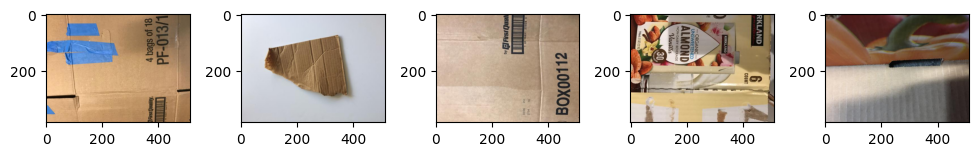

In [ ]:
plot_imgs(datapath+'/cardboard')

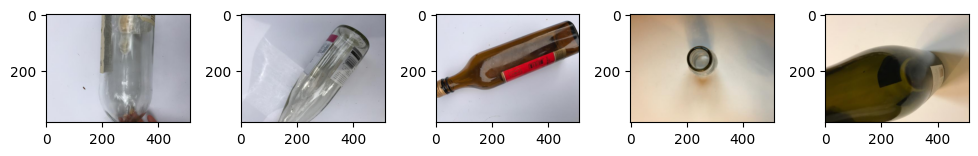

In [ ]:
plot_imgs(datapath+'/glass')

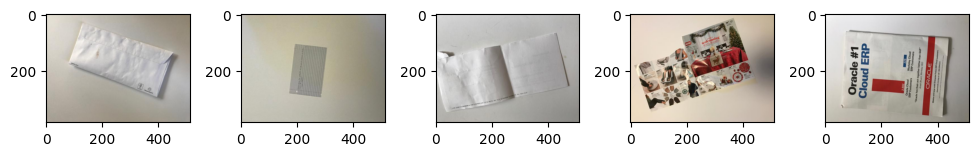

In [ ]:
plot_imgs(datapath+'/paper')

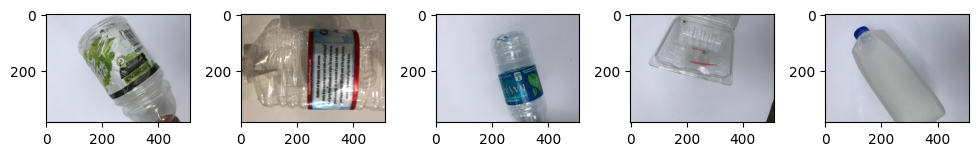

In [ ]:
plot_imgs(datapath+'/plastic')

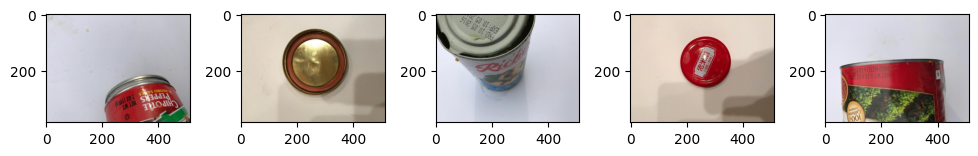

In [ ]:
plot_imgs(datapath+'/metal')

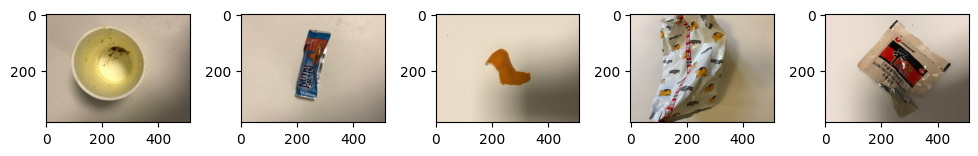

In [ ]:
plot_imgs(datapath+'/trash')



## Data Generator

In [ ]:
batch_size = 32
target_size = (224,224) #512x384

Found 2276 images belonging to 6 classes.
Found 251 images belonging to 6 classes.


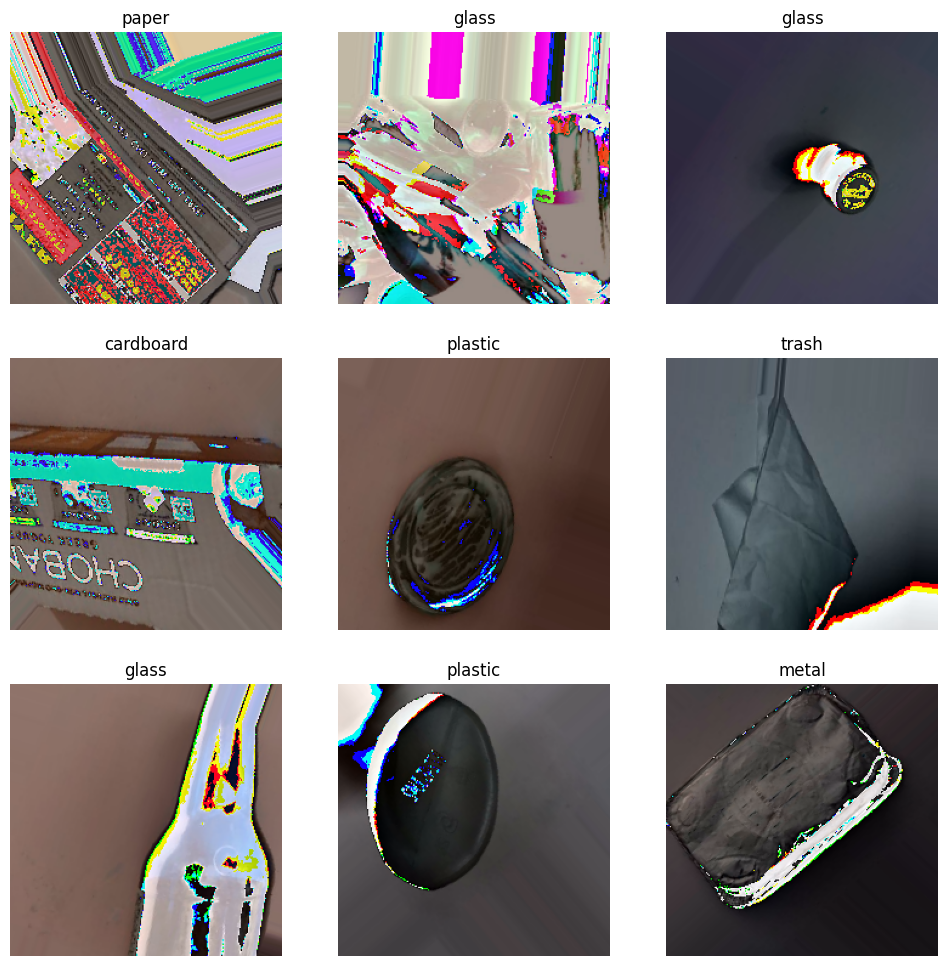

In [ ]:
train_datagen=ImageDataGenerator(
    preprocessing_function=tf.keras.applications.resnet50.preprocess_input,
    rotation_range=60,
    horizontal_flip=True,
    vertical_flip=True,
    validation_split=0.1,
    shear_range = 0.2,
    zoom_range = 0.2,
    width_shift_range = 0.2,
    height_shift_range = 0.2,
)
test_datagen=ImageDataGenerator(
    preprocessing_function=tf.keras.applications.resnet50.preprocess_input,
    validation_split=0.1
)

train_generator=train_datagen.flow_from_directory(datapath,target_size=target_size,batch_size=batch_size,class_mode='categorical',subset='training')
test_generator=test_datagen.flow_from_directory(datapath,target_size=target_size,batch_size=batch_size,class_mode='categorical',subset='validation')

class_names = list(train_generator.class_indices.keys())
images, labels = next(train_generator)
plt.figure(figsize=(12, 12))
for i in range(9):  # Display 9 images in a 3x3 grid
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].astype('uint8'))
    plt.title(class_names[np.argmax(labels[i])])
    plt.axis('off')
plt.show()

In [ ]:
labels = list(train_generator.class_indices.keys())
print(labels)

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


## Build Model

In [ ]:
num_classes = len(labels)

In [ ]:
input_shape = (224,224,3)

In [ ]:
# Load ResNet50 base model with ImageNet pre-trained weights (exclude top classifier)
base_model = tf.keras.applications.resnet.ResNet50(
    input_shape=input_shape,
    include_top=False,
    weights='imagenet'
)

model = Sequential()

# Freeze the ResNet50 base to preserve pre-trained ImageNet features
# Only the custom head layers will be trained in phase 1
base_model.trainable=False

# Add frozen ResNet50 base as feature extractor
model.add(base_model)

# add global average pooling layer
model.add(GlobalAveragePooling2D())

# add densely-connected NN layer with 512 hidden units
model.add(Dense(units=512, activation='relu'))  # use ReLU activation function
model.add(BatchNormalization())                 # normalize and scale inputs or activations
model.add(Dropout(0.2))                         # applies dopout to the input which will randomly disable 20% of hidden units

# add densely-connected NN layer with 128 hidden units
model.add(Dense(units=128, activation='relu')) # use ReLU activation function
model.add(BatchNormalization())                # normalize and scale inputs or activations
model.add(Dropout(0.2))                        # applies dopout to the input which will randomly disable 20% of hidden units

# add densely-connected NN layer with 6 hidden units
model.add(Dense(units=6, activation='softmax')) # use Softmax activation function to do final predictions
model.summary()
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

94765736/94765736 [==============================] - 1s 0us/step
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 7, 7, 2048)        23587712  
                                                                 
 global_average_pooling2d (  (None, 2048)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 512)               1049088   
                                                                 
 batch_normalization (Batch  (None, 512)               2048      
 Normalization)                                                  
                                                                 
 dropout (Dropout)           (None, 512)               0         
                                                         

## Train Model

In [ ]:
num_epochs = 30
STEP_SIZE_TRAIN=train_generator.samples/train_generator.batch_size
STEP_SIZE_TEST =test_generator.samples/test_generator.batch_size

print(STEP_SIZE_TRAIN)
print(STEP_SIZE_TEST)

71.125
7.84375


In [ ]:
es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=10)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001)

#step 1
history = model.fit(
    train_generator,
    steps_per_epoch=STEP_SIZE_TRAIN,
    epochs=num_epochs,
    validation_data=test_generator,
    validation_steps=STEP_SIZE_TEST,
    # verbose=1,
    callbacks = [es, reduce_lr],)
loss = history.history['loss']
validation_loss = history.history['val_loss']
accuracy = history.history['accuracy']
validation_accuracy =history.history['val_accuracy']

#step 2
base_model.trainable=True
history = model.fit(
    train_generator,
    steps_per_epoch=STEP_SIZE_TRAIN,
    epochs=num_epochs,
    validation_data=test_generator,
    validation_steps=STEP_SIZE_TEST,
    # verbose=1,
    callbacks = [es, reduce_lr],)
loss.extend(history.history['loss'])
validation_loss.extend(history.history['val_loss'])
accuracy.extend(history.history['accuracy'])
validation_accuracy.extend(history.history['val_accuracy'])

Epoch 1/30
71/71 [==============================] - 47s 491ms/step - loss: 1.3011 - accuracy: 0.5422 - val_loss: 0.7387 - val_accuracy: 0.7490 - lr: 1.0000e-04
Epoch 2/30
71/71 [==============================] - 32s 449ms/step - loss: 0.7321 - accuracy: 0.7346 - val_loss: 0.5525 - val_accuracy: 0.8048 - lr: 1.0000e-04
Epoch 3/30
71/71 [==============================] - 32s 445ms/step - loss: 0.5990 - accuracy: 0.7865 - val_loss: 0.4220 - val_accuracy: 0.8406 - lr: 1.0000e-04
Epoch 4/30
71/71 [==============================] - 37s 520ms/step - loss: 0.5283 - accuracy: 0.8128 - val_loss: 0.3596 - val_accuracy: 0.8725 - lr: 1.0000e-04
Epoch 5/30
71/71 [==============================] - 32s 455ms/step - loss: 0.4802 - accuracy: 0.8313 - val_loss: 0.3200 - val_accuracy: 0.9004 - lr: 1.0000e-04
Epoch 6/30
71/71 [==============================] - 33s 467ms/step - loss: 0.4415 - accuracy: 0.8453 - val_loss: 0.3255 - val_accuracy: 0.9004 - lr: 1.0000e-04
Epoch 7/30
71/71 [======================

## Save Model

In [ ]:
drive.mount('/content/drive')
models.save_model(model, 'garbage_cnn.h5')
!tar -zcvf garbage_cnn.h5.tgz garbage_cnn.h5
!cp garbage_cnn.h5.tgz /content/drive/MyDrive/CapstoneProject/

Mounted at /content/drive


<ipython-input-19-66fc54a89505>:2: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  models.save_model(model, 'garbage_cnn.h5')


garbage_cnn.h5


## Evaluate Model

In [ ]:
# Evaluate Model
los, acc = model.evaluate(test_generator, steps=STEP_SIZE_TEST)
print("The accuracy of the model is {:.3f}\nThe Loss in the model is {:.3f}".format(acc,los))

7/7 [==============================] - 1s 133ms/step - loss: 0.2307 - accuracy: 0.9243
The accuracy of the model is 0.924
The Loss in the model is 0.231


## Training History

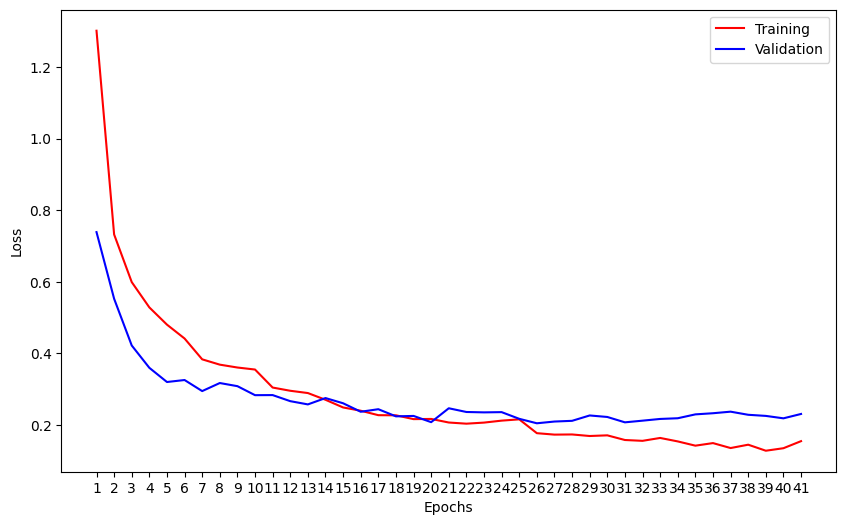

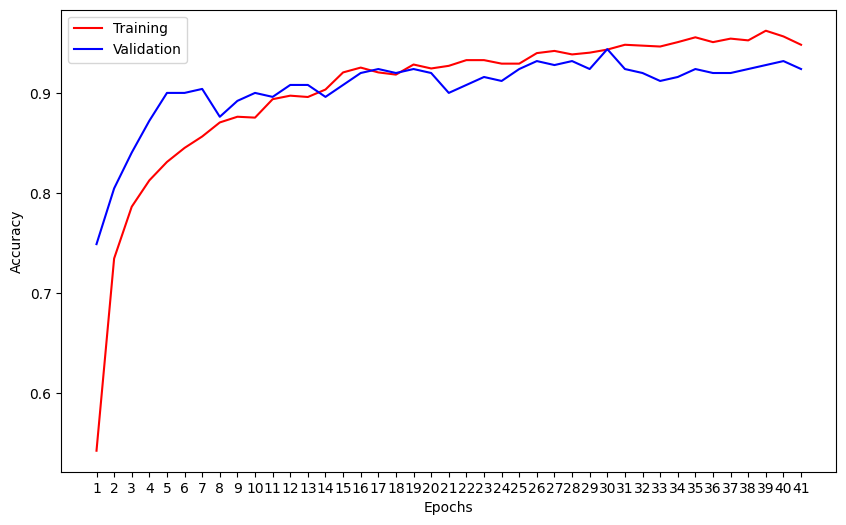

In [ ]:
epochs = range(1, len(loss)+1)

fig1 = plt.figure(figsize=(10,6))
plt.plot(epochs,loss,c="red",label="Training")
plt.plot(epochs,validation_loss,c="blue",label="Validation")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()

epochs1 = range(1, len(accuracy)+1)

fig2 = plt.figure(figsize=(10,6))
plt.plot(epochs1,accuracy,c="red",label="Training")
plt.plot(epochs1,validation_accuracy,c="blue",label="Validation")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.xticks(epochs1)
plt.legend()

## Confusion Matrix

1/1 [==============================] - 1s 1s/step


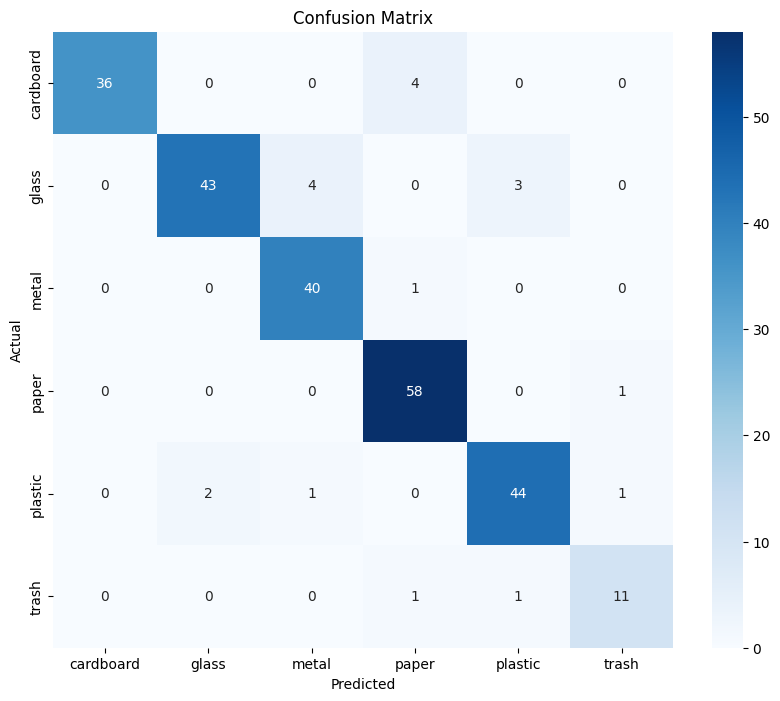

In [ ]:
true_labels = []
predictions = []

# Iterate through the validation data
for i in range(len(test_generator)):
    x_batch, y_batch = test_generator[i]
    preds = model.predict(x_batch)
    true_labels.extend(np.argmax(y_batch, axis=1))
    predictions.extend(np.argmax(preds, axis=1))

true_labels = np.array(true_labels)
predictions = np.array(predictions)

# Build confusion matrix
cm = confusion_matrix(true_labels, predictions)

# Get class names from the generator
class_names = list(test_generator.class_indices.keys())

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

### Classification Report

In [ ]:
# Classification report
report = classification_report(true_labels, predictions, target_names=class_names)
print(report)
print('\n')

              precision    recall  f1-score   support

   cardboard       1.00      0.90      0.95        40
       glass       0.96      0.86      0.91        50
       metal       0.89      0.98      0.93        41
       paper       0.91      0.98      0.94        59
     plastic       0.92      0.92      0.92        48
       trash       0.85      0.85      0.85        13

    accuracy                           0.92       251
   macro avg       0.92      0.91      0.91       251
weighted avg       0.93      0.92      0.92       251





## Testing

### Testing 1

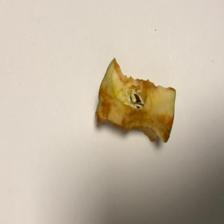

In [ ]:
from PIL import Image
path = 'Garbage classification/Garbage classification/trash/trash101.jpg'
img = Image.open(path)
img = img.resize((224, 224))
display(img)
x = keras.preprocessing.image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = tf.keras.applications.resnet50.preprocess_input(x)


In [ ]:
labels = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
classes = model.predict(x)
pred = labels[np.argmax(classes)]
print(classes)
print(pred)

1/1 [==============================] - 1s 823ms/step
[[1.8485911e-05 4.0883486e-05 1.0789023e-03 4.4900851e-04 6.2767424e-07
  9.9841213e-01]]
trash


### Testing 2

In [ ]:
import urllib.request
urllib.request.urlretrieve("https://external-content.duckduckgo.com/iu/?u=https%3A%2F%2Ftse3.mm.bing.net%2Fth%3Fid%3DOIP.nN_-2TLzeXfN6PiuZDL08wHaEv%26pid%3DApi&f=1", "cardboard.jpg")

('cardboard.jpg', <http.client.HTTPMessage at 0x78d1e84370a0>)

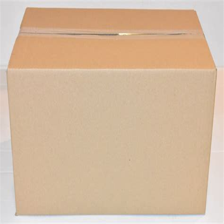

In [ ]:
from PIL import Image
path = 'cardboard.jpg'
img = Image.open(path)
img = img.resize((224, 224))
display(img)
x = keras.preprocessing.image.img_to_array(img)
x = tf.keras.applications.resnet50.preprocess_input(x)
x = np.expand_dims(x, axis=0)



In [ ]:
labels = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
classes = model.predict(x)
pred = labels[np.argmax(classes)]
print(classes)
print(pred)

1/1 [==============================] - 0s 31ms/step
[[0.8262849  0.00108897 0.00267026 0.08104245 0.00238359 0.0865299 ]]
cardboard
